# Assignment 2 — Keras MNIST Classifier

**DATAX504** · Due end of Week 4

## Tasks
1. Dense classifier on MNIST — test accuracy **without** dropout
2. Same architecture **with** dropout — compare train vs val curves
3. Confusion matrix → worst confused digit pair
4. Explain why `sparse_categorical_crossentropy` is appropriate

## Moodle fields
`a2_repo`, `a2_test_acc`, `a2_test_acc_do`, `a2_worst_pair`, `a2_crossentropy`

## AI disclosure

Fill in before submission (see Assignment 1 template).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import keras
from keras import layers

## 1. Load MNIST

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

num_classes = 10
print(x_train_flat.shape, y_train.shape)

(60000, 784) (60000,)


## 2. Validation split

In [3]:
val_samples = 10000
x_val = x_train_flat[:val_samples]
y_val = y_train[:val_samples]
x_train_flat = x_train_flat[val_samples:]
y_train = y_train[val_samples:]

print("Train:", x_train_flat.shape[0], "Val:", x_val.shape[0], "Test:", x_test_flat.shape[0])

Train: 50000 Val: 10000 Test: 10000


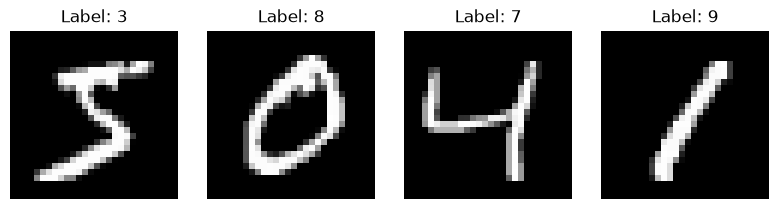

In [4]:
plt.figure(figsize=(10, 4))

for i in range(4):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 0.003921569


## 3. Model builder

TODO: adjust hidden units if needed. Keep architecture comparable between runs.

In [6]:
def build_model(use_dropout=False, dropout_rate=0.3):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
    ])
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation="softmax"))
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

## 4. Train baseline (no dropout)

In [7]:
EPOCHS = 20
BATCH_SIZE = 128

model_baseline = build_model(use_dropout=False)
history_baseline = model_baseline.fit(
    x_train_flat, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1,
)

test_loss, test_acc = model_baseline.evaluate(x_test_flat, y_test, verbose=0)
print(f"Baseline test accuracy (Moodle a2_test_acc): {test_acc:.4f}")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9285 - loss: 0.2484 - val_accuracy: 0.9586 - val_loss: 0.1407
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9729 - loss: 0.0900 - val_accuracy: 0.9747 - val_loss: 0.0839
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9824 - loss: 0.0570 - val_accuracy: 0.9777 - val_loss: 0.0747
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9879 - loss: 0.0378 - val_accuracy: 0.9753 - val_loss: 0.0830
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9912 - loss: 0.0277 - val_accuracy: 0.9772 - val_loss: 0.0801
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9924 - loss: 0.0221 - val_accuracy: 0.9773 - val_loss: 0.0820
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9942 - loss: 0.0174 - val_accuracy: 0.9761 - val_loss: 0.0871
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9950 - loss: 0.0157 - val_accuracy: 0.

## 5. Train with dropout

In [8]:
model_dropout = build_model(use_dropout=True, dropout_rate=0.3)
history_dropout = model_dropout.fit(
    x_train_flat, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1,
)

_, test_acc_do = model_dropout.evaluate(x_test_flat, y_test, verbose=0)
print(f"Dropout test accuracy (Moodle a2_test_acc_do): {test_acc_do:.4f}")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9170 - loss: 0.2789 - val_accuracy: 0.9642 - val_loss: 0.1225
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9680 - loss: 0.1047 - val_accuracy: 0.9742 - val_loss: 0.0876
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9785 - loss: 0.0685 - val_accuracy: 0.9763 - val_loss: 0.0770
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9839 - loss: 0.0494 - val_accuracy: 0.9775 - val_loss: 0.0728
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9889 - loss: 0.0351 - val_accuracy: 0.9778 - val_loss: 0.0722
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9907 - loss: 0.0275 - val_accuracy: 0.9785 - val_loss: 0.0745
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9926 - loss: 0.0232 - val_accuracy: 0.9804 - val_loss: 0.0725
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9944 - loss: 0.0174 - val_accuracy: 0.

**Build the model without dropout**

In [9]:
model_without_dropout = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_without_dropout.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Model without dropout**

In [10]:
model_without_dropout.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
test_loss_without_dropout, test_accuracy_without_dropout = (
    model_without_dropout.evaluate(x_test, y_test, verbose=0)
)

print(f"Test loss without dropout: {test_loss_without_dropout:.4f}")
print(f"Test accuracy without dropout: {test_accuracy_without_dropout:.4f}")

Test loss without dropout: 2.3027
Test accuracy without dropout: 0.0788


## 6. Compare learning curves

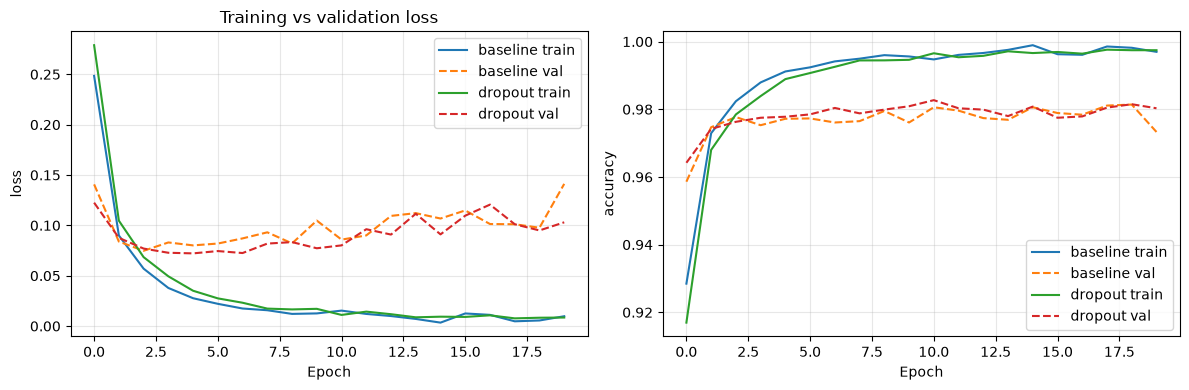

In [15]:
def plot_histories(histories, labels, metric="loss"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for hist, label in zip(histories, labels):
        axes[0].plot(hist.history[metric], label=f"{label} train")
        axes[0].plot(hist.history[f"val_{metric}"], linestyle="--", label=f"{label} val")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel(metric)
    axes[0].legend()
    axes[0].set_title(f"Training vs validation {metric}")
    axes[0].grid(True, alpha=0.3)
    # accuracy panel
    for hist, label in zip(histories, labels):
        axes[1].plot(hist.history["accuracy"], label=f"{label} train")
        axes[1].plot(hist.history["val_accuracy"], linestyle="--", label=f"{label} val")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_histories([history_baseline, history_dropout], ["baseline", "dropout"])

## 7. Confusion matrix

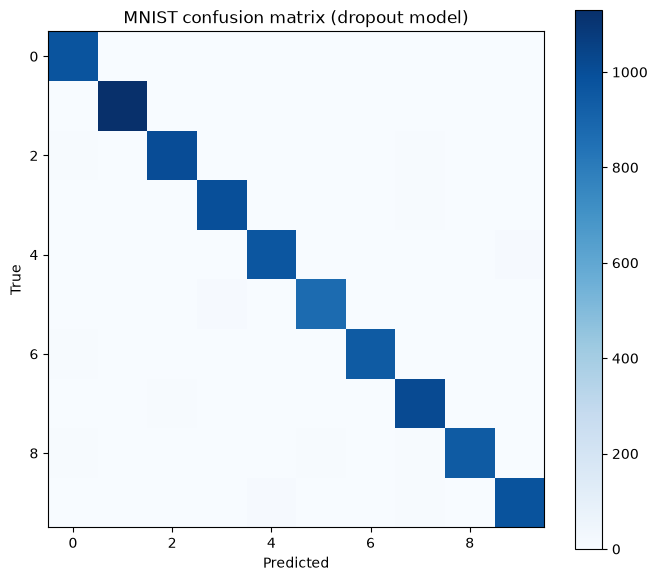

Worst confused pair (Moodle a2_worst_pair): 5-3 (13 errors)


In [14]:
y_pred = np.argmax(model_dropout.predict(x_test_flat, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("MNIST confusion matrix (dropout model)")
plt.show()

# TODO: find off-diagonal maximum → worst pair for Moodle a2_worst_pair
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
true_i, pred_j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
print(f"Worst confused pair (Moodle a2_worst_pair): {true_i}-{pred_j} ({cm_off[true_i, pred_j]} errors)")

## 8. Why sparse categorical crossentropy? (Moodle `a2_crossentropy`)

Write up to 150 words explaining:
- What integer labels look like vs one-hot
- What the loss computes
- Why this pairs with a softmax output

*Your answer here.*
Sparse categorical crossentropy is appropriate for MNIST because it is a multi-class classification problem with ten mutually exclusive classes representing digits 0 to 9. Each image belongs to only one class, and the labels are stored as integers, such as 5, rather than one-hot encoded vectors like [0,0,0,0,0,1,0,0,0,0]. The model’s final softmax layer produces a probability for each of the ten digits, with all probabilities adding up to one. Sparse categorical crossentropy calculates the negative logarithm of the probability assigned to the correct class. Therefore, a high probability for the true digit gives a low loss, while a low probability gives a high loss. It is called “sparse” because it works directly with integer labels. Standard categorical crossentropy would require one-hot encoded labels. Therefore, this loss function is efficient and well suited to MNIST.